In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
import joblib

plt.style.use('default')

In [ ]:
# Load your dataset
df = pd.read_csv('/content/raw_trend_data2.csv.csv')

# Preview
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


In [ ]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nSummary:")
df.describe()

Shape: (12000, 28)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   post_id                  12000 non-null  object 
 1   timestamp                12000 non-null  object 
 2   day_of_week              12000 non-null  object 
 3   platform                 12000 non-null  object 
 4   user_id                  12000 non-null  object 
 5   location                 12000 non-null  object 
 6   language                 12000 non-null  object 
 7   text_content             12000 non-null  object 
 8   hashtags                 12000 non-null  object 
 9   mentions                 8059 non-null   object 
 10  keywords                 12000 non-null  object 
 11  topic_category           12000 non-null  object 
 12  sentiment_score          12000 non-null  float64
 13  sentiment_label          12000 non-null  object 
 

,sentiment_score,toxicity_score,likes_count,shares_count,comments_count,impressions,engagement_rate,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
count,12000.000000,12000.000000,12000.00000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.000553,0.503868,2490.72025,1007.167167,504.34575,49811.338500,0.278137,0.001472,0.000998,0.729692
std,0.583563,0.288198,1441.53253,575.072282,288.68416,28930.289451,1.149206,0.576627,0.289940,57.787219
min,-0.999800,0.000000,0.00000,0.000000,0.00000,130.000000,0.001880,-0.999600,-0.499900,-99.900000
25%,-0.503200,0.251400,1236.00000,510.000000,253.00000,24716.500000,0.049100,-0.495975,-0.248400,-48.700000
50%,-0.006200,0.505950,2496.00000,1018.000000,503.00000,49674.000000,0.080605,0.001950,0.002800,0.900000
75%,0.513525,0.756200,3723.25000,1501.000000,755.00000,74815.000000,0.163123,0.501725,0.250700,50.100000
max,0.999900,0.999900,5000.00000,2000.000000,1000.00000,99997.000000,32.211710,0.999400,0.499900,99.900000


In [ ]:
# Convert date column (update column name if different)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['timestamp'])

# Sort by date
df = df.sort_values('timestamp')

# Fill missing values
df = df.ffill()

df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
6988,f2cwealuvg9p,2024-05-01 01:04:04,Wednesday,YouTube,user_f2e0sgwi,"Rio de Janeiro, Brazil",en,Feeling let down with my new Pixel Watch from ...,"#Premium, #Lifestyle, #ProductLaunch",@TechHelp,...,555,12929,0.30396,Google,Pixel Watch,LoyaltyRewards,Post-Launch,-0.0435,0.1599,-5.3
2147,rx6kw7dl1hql,2024-05-01 01:35:53,Wednesday,Twitter,user_23qq6msj,"Dubai, UAE",fr,Attended the Apple CustomerFirst event yesterd...,"#Fashion, #Quality","@InfluencerName, @ProductTeam",...,812,72636,0.04901,Apple,Apple Watch,BackToSchool,Post-Launch,0.0324,0.4368,-94.6
9981,kzo4myed0f9j,2024-05-01 02:24:32,Wednesday,Twitter,user_x8o6o3mx,"Barcelona, Spain",ru,Pepsi ValentinesDeals is subpar! Can't wait to...,"#Tech, #SpecialOffer",@BrandCEO,...,284,76663,0.03160,Pepsi,Diet Pepsi,GlobalCampaign,Launch,-0.7461,-0.4979,45.4
6000,dcn4gxvn0cnk,2024-05-01 04:21:58,Wednesday,Reddit,user_8g3sp91m,"Tokyo, Japan",pt,Attended the Google LaunchWave event yesterday...,"#Sale, #Fashion",@BrandCEO,...,886,70729,0.04934,Google,Pixel Buds,InnovationX,Launch,-0.3028,-0.3483,-83.6
1431,ae40vtfvawtf,2024-05-01 04:39:36,Wednesday,Instagram,user_nxcw2tat,"Sydney, Australia",zh,Super excited with my new Xbox Elite Controlle...,#Lifestyle,@BrandCEO,...,687,18206,0.28798,Microsoft,Xbox Elite Controller,LocalTouchpoints,Post-Launch,-0.0720,0.1482,-62.2


In [ ]:
# Rolling features
df['rolling_mean'] = df['impressions'].rolling(window=7).mean()
df['rolling_std'] = df['impressions'].rolling(window=7).std()

# Lag feature
df['lag_1'] = df['impressions'].shift(1)

# Time features
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Drop nulls created by rolling/lag
df = df.dropna()

df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate,rolling_mean,rolling_std,lag_1,day,month
11483,ubargw6tb937,2024-05-01 05:47:38,2,Facebook,user_4i74hh3x,"Milan, Italy",en,Just unboxed my new RAV4 from Toyota. Disappoi...,#Food,"@StyleGuide, @CompetitorBrand",...,BackToSchool,Launch,0.9545,-0.4810,30.4,42820.857143,29735.487617,36661.0,1,5
4912,gt9ptph8t1yw,2024-05-01 05:56:58,2,Reddit,user_18g2mo7l,"Johannesburg, South Africa",ar,Anyone have tips about Coca-Cola's Coke Zero? ...,"#Eco, #Innovation","@StyleGuide, @CompetitorBrand",...,CustomerFirst,Post-Launch,0.3738,-0.0517,-14.1,51572.857143,28459.623559,11922.0,1,5
8967,vfwbian66kv9,2024-05-01 06:08:47,2,Reddit,user_cw64910v,"Lagos, Nigeria",ar,Just tried the Apple Watch from Apple. Disappo...,#Premium,@BrandSupport,...,SustainableFuture,Launch,0.8584,-0.3658,1.1,44113.857143,28858.568586,74193.0,1,5
7070,h7bdlby9s7wa,2024-05-01 06:16:01,2,Twitter,user_7gvpizhg,"Johannesburg, South Africa",en,Comparing Coca-Cola Fanta to the competition. ...,#Sale,@InfluencerName,...,CyberMonday,Launch,0.7311,0.4388,3.2,43129.142857,27655.334672,20423.0,1,5
2221,8mq28zl0awbw,2024-05-01 07:06:43,2,Twitter,user_8nvzxsuj,"Vancouver, Canada",es,Bummed out with my new Ultraboost from Adidas!...,"#Sustainable, #Fitness, #Affordable",@StyleGuide,...,CyberMonday,Post-Launch,0.2630,-0.2378,-51.6,41921.428571,26405.513723,69770.0,1,5


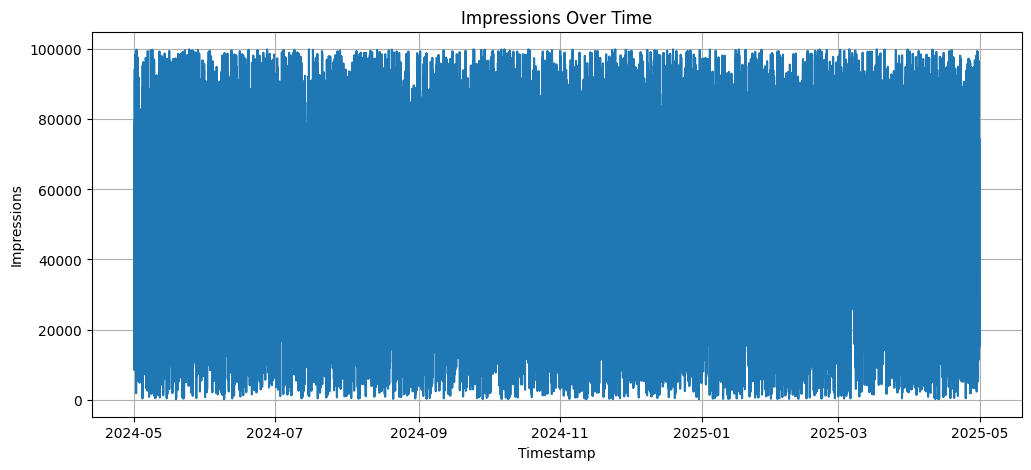

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['impressions'])
plt.title("Impressions Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Impressions")
plt.grid(True)
plt.show()

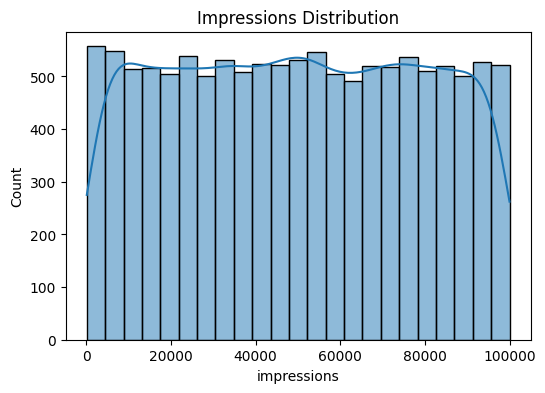

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['impressions'], kde=True)
plt.title("Impressions Distribution")
plt.show()

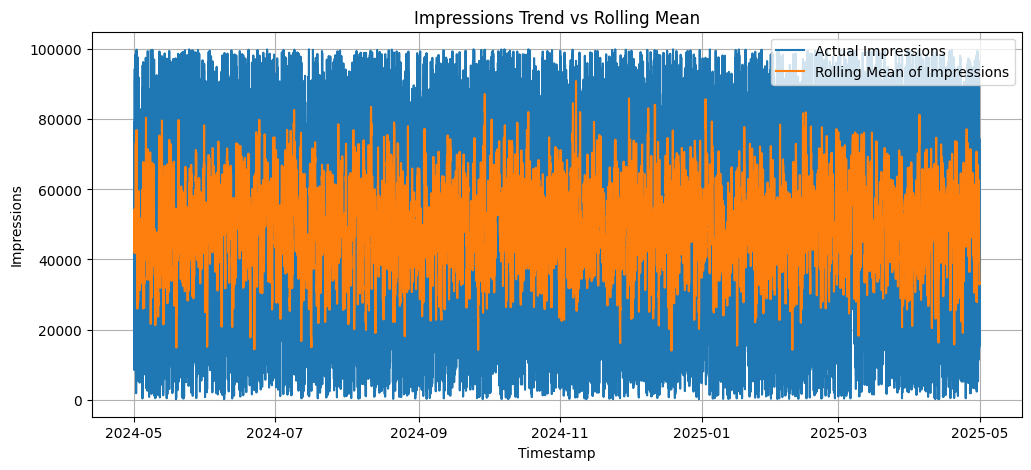

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['impressions'], label='Actual Impressions')
plt.plot(df['timestamp'], df['rolling_mean'], label='Rolling Mean of Impressions')
plt.legend()
plt.title("Impressions Trend vs Rolling Mean")
plt.xlabel("Timestamp")
plt.ylabel("Impressions")
plt.grid(True)
plt.show()

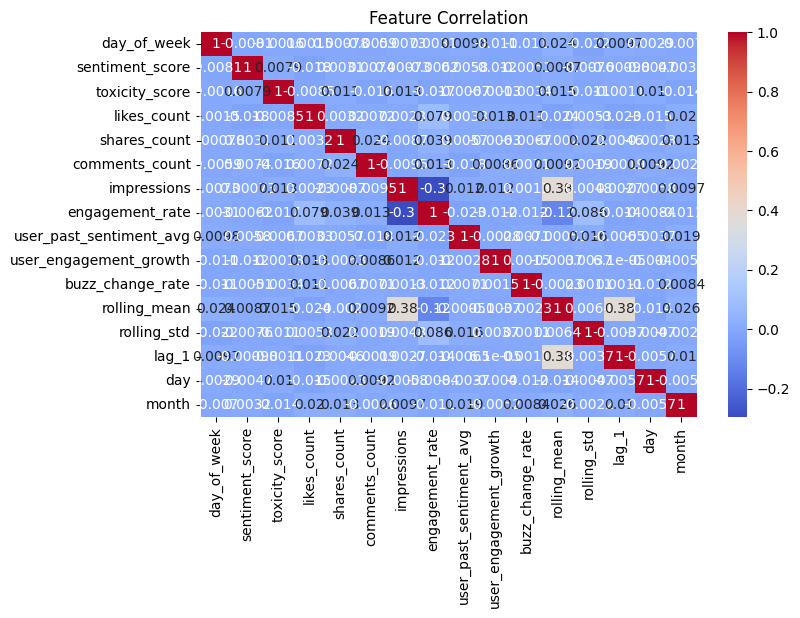

In [ ]:
plt.figure(figsize=(8,5))
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['number'])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [35]:
features = [
    'rolling_mean',
    'rolling_std',
    'lag_1'
]

X = df[features]

In [36]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(X)

IsolationForest(contamination=0.05, random_state=42)

In [37]:
df['anomaly'] = model.predict(X)

# Convert to readable labels
df['anomaly_label'] = df['anomaly'].apply(
    lambda x: "Anomaly" if x == -1 else "Normal"
)

df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate,rolling_mean,rolling_std,lag_1,day,month,anomaly,anomaly_label
11483,ubargw6tb937,2024-05-01 05:47:38,2,Facebook,user_4i74hh3x,"Milan, Italy",en,Just unboxed my new RAV4 from Toyota. Disappoi...,#Food,"@StyleGuide, @CompetitorBrand",...,0.9545,-0.4810,30.4,42820.857143,29735.487617,36661.0,1,5,1,Normal
4912,gt9ptph8t1yw,2024-05-01 05:56:58,2,Reddit,user_18g2mo7l,"Johannesburg, South Africa",ar,Anyone have tips about Coca-Cola's Coke Zero? ...,"#Eco, #Innovation","@StyleGuide, @CompetitorBrand",...,0.3738,-0.0517,-14.1,51572.857143,28459.623559,11922.0,1,5,1,Normal
8967,vfwbian66kv9,2024-05-01 06:08:47,2,Reddit,user_cw64910v,"Lagos, Nigeria",ar,Just tried the Apple Watch from Apple. Disappo...,#Premium,@BrandSupport,...,0.8584,-0.3658,1.1,44113.857143,28858.568586,74193.0,1,5,1,Normal
7070,h7bdlby9s7wa,2024-05-01 06:16:01,2,Twitter,user_7gvpizhg,"Johannesburg, South Africa",en,Comparing Coca-Cola Fanta to the competition. ...,#Sale,@InfluencerName,...,0.7311,0.4388,3.2,43129.142857,27655.334672,20423.0,1,5,1,Normal
2221,8mq28zl0awbw,2024-05-01 07:06:43,2,Twitter,user_8nvzxsuj,"Vancouver, Canada",es,Bummed out with my new Ultraboost from Adidas!...,"#Sustainable, #Fitness, #Affordable",@StyleGuide,...,0.2630,-0.2378,-51.6,41921.428571,26405.513723,69770.0,1,5,1,Normal


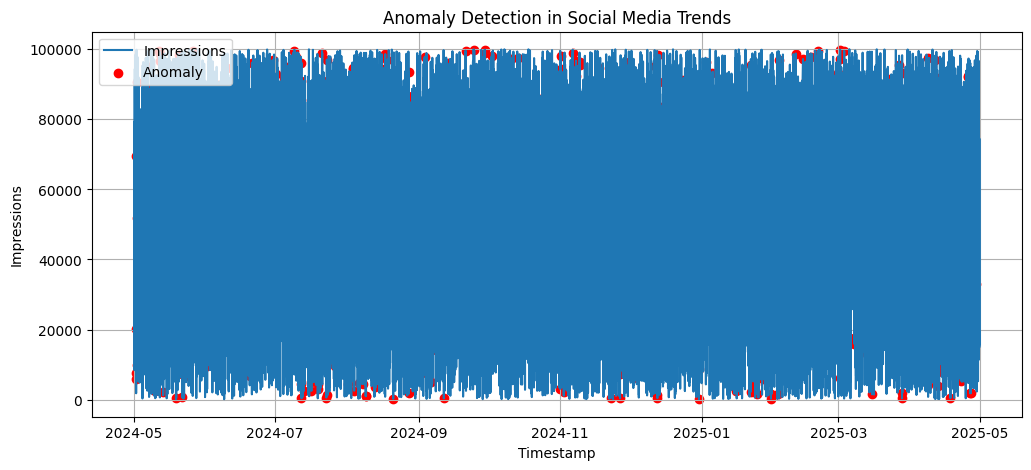

In [39]:
plt.figure(figsize=(12,5))

plt.plot(df['timestamp'], df['impressions'], label='Impressions')

anomalies = df[df['anomaly'] == -1]

plt.scatter(
    anomalies['timestamp'],
    anomalies['impressions'],
    color='red',
    label='Anomaly'
)

plt.legend()
plt.title("Anomaly Detection in Social Media Trends")
plt.xlabel("Timestamp")
plt.ylabel("Impressions")
plt.grid(True)
plt.show()

In [41]:
import os

output_dir = '../data'
os.makedirs(output_dir, exist_ok=True)
df.to_csv(os.path.join(output_dir, 'processed_trend_data.csv'), index=False)

In [43]:
import os

output_dir = '../models'
os.makedirs(output_dir, exist_ok=True)
joblib.dump(model, os.path.join(output_dir, 'isolation_forest.pkl'))

['../models/isolation_forest.pkl']